# Identifying Potential Starbucks Hotspots in the Contiguous United States (CONUS)

**Question and study area**: Where are the Starbucks hotspots in the continental United States?

**Rate and stable key**: We use a stores_per_100k residents. The stable key is the GEOID of each county.

**Strict neighbor rule**: We only choose neighbors that share a meaningful boundary length of more than 0 meters.

**Python alignment and islands policy**: PostGIS handles everything until generating the focal GEOID and neighbor GEOID. Python and PySAL handle everything after.

**Significance screen**: We filter to quadrant=1, which is the high-high quadrant, and the rows where the p-value is below 0.05.

**Validation evidence saved**: We run PostGIS validation checks while preparing the neighbor JSON and assert statements for the PySAL transformation.

**Interpretation limit**: We can't definitively explain why these are neighbors, only that they're statistically significant.

**Final remaining action, if any**: 
- We could make better visualizations, but with a basic visualization, I declare a v1 of this project complete and demonstrates the important part, which is the PostGIS and PySAL concepts and methods.
- We could use a more stringent boundary filter, like more than 1 meter, or some informed value that reflects a statistical filtering eliminating all potential slivers in the dataset.

## Imports

In [25]:
import duckdb
import geopandas as gpd
import numpy as np
import pandas as pd
from libpysal.weights import W
from esda.moran import Moran_Local
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json

## Initial Visualization

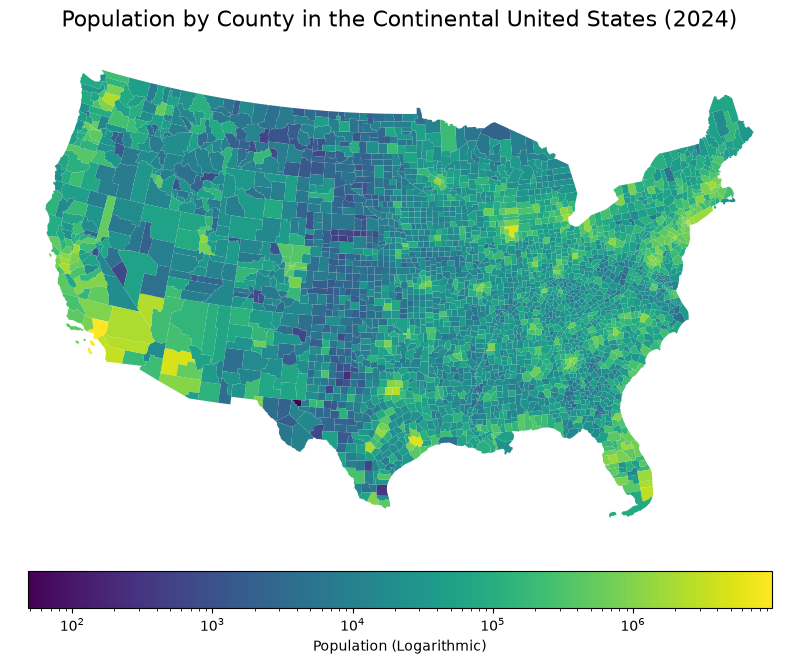

In [58]:
# counties polygon data from census TIGER/Line shapefiles

counties_original = gpd.read_parquet('data/us_county_population_with_geometry.parquet')
for state in ['Alaska', 'Hawaii', 'Puerto Rico']:
    counties_original = counties_original[counties_original['state_name'] != state]

counties = counties_original.to_crs('EPSG:5070')

fig1, ax1 = plt.subplots(figsize=(12, 8))

counties.plot(
    column='pop_2024',
    ax=ax1,
    cmap='viridis',
    legend=True,
    norm=colors.LogNorm(vmin=counties['pop_2024'].min(), vmax=counties['pop_2024'].max()),
    figsize=(12, 8),
    legend_kwds={
        'label': "Population (Logarithmic)",
        'orientation': "horizontal", 
        "shrink": 0.8,
        "pad": 0.05}
)

ax1.set_title(
    "Population by County in the Continental United States (2024)",
    fontsize=16,
    pad=15,
)

ax1.set_axis_off()

In [59]:
assert counties.crs is not None, "counties has no CRS"
assert counties.crs.to_epsg() == 5070, \
    f"Expected EPSG:5070, got {counties.crs}"

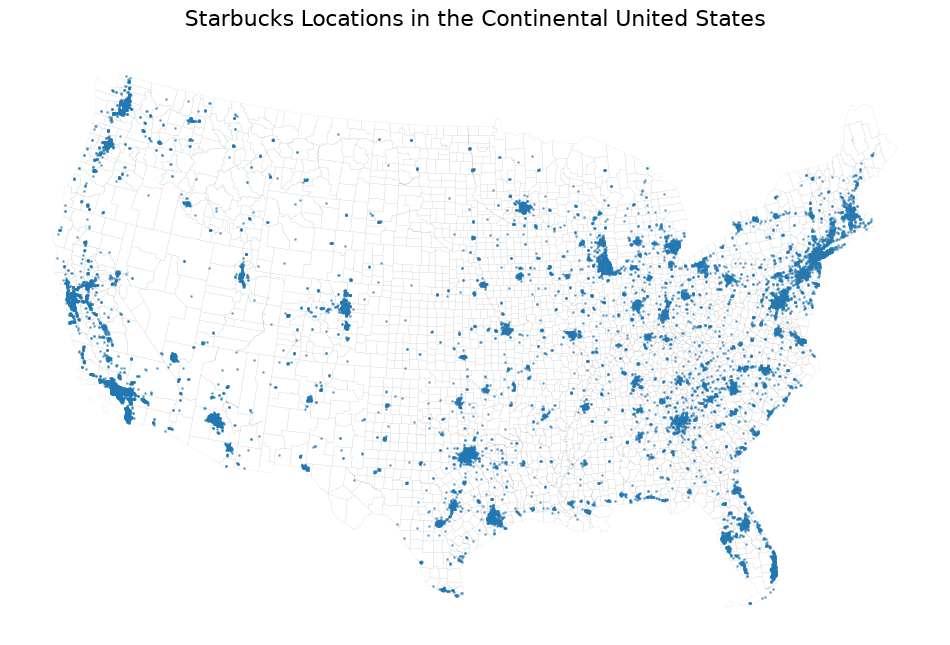

In [62]:
# starbucks point data from osmnx

starbucks_original = gpd.read_parquet('data/usa_starbucks_with_geometry.parquet')
for name in ['AK', 'HI', 'PR']:
    starbucks_original = starbucks_original[starbucks_original['state'] != name]

starbucks = starbucks_original.to_crs('EPSG:5070')

fig2, ax2 = plt.subplots(figsize=(12, 8))

starbucks.plot(
    ax=ax2,
    markersize=1,
    alpha=0.5,
)

ax2.set_title(
    "Starbucks Locations in the Continental United States",
    fontsize=16,
    pad=15,
)

counties.plot(
    ax=ax2,
    facecolor='none',
    edgecolor='grey',
    linewidth=0.1,
    alpha=0.5
)

ax2.set_axis_off()

In [3]:
assert starbucks.crs is not None, "starbucks has no CRS"
assert starbucks.crs.to_epsg() == 5070, \
    f"Expected EPSG:5070, got {starbucks.crs}"

## Prepare Data

In [6]:
# convert geometry to WKB
# register layers with duckdb
# convert the wkb back to duckdb's native geometry type

counties_sql = counties.copy()
counties_sql["geometry"] = counties_sql.geometry.to_wkb()

starbucks_sql = starbucks.copy()
starbucks_sql["geometry"] = starbucks_sql.geometry.to_wkb()
import duckdb

con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

con.register("counties_raw", counties_sql)
con.register("starbucks_raw", starbucks_sql)

con.execute("""
create or replace view counties as
select
    * exclude geometry
    ,st_geomfromwkb(geometry) as geometry
from counties_raw;
""")

con.execute("""
create or replace view starbucks as
select
    * exclude geometry,
    st_geomfromwkb(geometry) as geometry
from starbucks_raw;
""")

/var/folders/n3/q8wb235x57n_sx2q14dsngjr0000gn/T/ipykernel_3869/788814338.py:6: UserWarning: Geometry column does not contain geometry.
  counties_sql["geometry"] = counties_sql.geometry.to_wkb()
/var/folders/n3/q8wb235x57n_sx2q14dsngjr0000gn/T/ipykernel_3869/788814338.py:9: UserWarning: Geometry column does not contain geometry.
  starbucks_sql["geometry"] = starbucks_sql.geometry.to_wkb()


In [7]:
query = """
with store_counts as (
    select
        c.GEOID
        ,count(s.id) as store_count
    from counties as c
    left join starbucks as s
        on st_contains(c.geometry, s.geometry)
    group by c.GEOID)
select
    c.GEOID
    ,c.county_name
    ,c.state_name
    ,c.pop_2024
    ,coalesce(sc.store_count, 0) as store_count
    ,round(
        coalesce(sc.store_count, 0)::numeric / nullif(c.pop_2024, 0) * 100000,
        2
    ) as stores_per_100k
    ,st_aswkb(c.geometry) as geometry
from counties as c
left join store_counts as sc
    on c.GEOID = sc.GEOID;
"""

df = con.execute(query).df()

df["geometry"] = df["geometry"].apply(bytes)

df["geometry"] = gpd.GeoSeries.from_wkb(
    df["geometry"]
    ,crs="EPSG:5070"
)

cs = gpd.GeoDataFrame(
    df
    ,geometry="geometry"
    ,crs="EPSG:5070"
)

same_geoids = set(cs["GEOID"]) == set(counties["GEOID"])

smt1 = "match." if same_geoids else "do not match."
smt2 = "unique." if cs["GEOID"].is_unique else "not unique."

print(
    f"Validation: The GEOIDs of the original counties table and "
    f"processed cs table {smt1}\n"
    f"The counties in the final cs table are {smt2}"
)

cs.head()

Validation: The GEOIDs of the original counties table and processed cs table match.
The counties in the final cs table are unique.


,GEOID,county_name,state_name,pop_2024,store_count,stores_per_100k,geometry
0,01001,Autauga County,Alabama,61464,2,3.25,"POLYGON ((879604.296 1076360.662, 879597.754 1..."
1,01003,Baldwin County,Alabama,261608,10,3.82,"POLYGON ((762188.702 922288.362, 762185.295 92..."
2,01005,Barbour County,Alabama,24358,1,4.11,"POLYGON ((997244.227 1011911.22, 997263.308 10..."
3,01007,Bibb County,Alabama,22258,0,0.00,"POLYGON ((845781.155 1146034.424, 845782.695 1..."
4,01009,Blount County,Alabama,60163,0,0.00,"POLYGON ((865977.151 1235870.784, 865853.104 1..."


## Calculate Neighbors Using Intersection Boundary Length

In [8]:
# register cs (counties-starbucks) table

cs_sql = cs.copy()
cs_sql["geometry"] = cs_sql.geometry.to_wkb()

con.register("cs_raw", cs_sql)

# IMPORTANT: NOTE cs_raw HERE! KEEP IT!
con.execute("""
create or replace view cs_spatial as
select
    * exclude geometry,
    st_geomfromwkb(geometry) as geometry
from cs_raw;
""")

/var/folders/n3/q8wb235x57n_sx2q14dsngjr0000gn/T/ipykernel_3869/2796234238.py:4: UserWarning: Geometry column does not contain geometry.
  cs_sql["geometry"] = cs_sql.geometry.to_wkb()


### 0. Prelminary dataset checks

In [9]:
display(
	con.execute("""
	describe cs_spatial;
	""").df()
)

,column_name,column_type,null,key,default,extra
0,GEOID,VARCHAR,YES,None,None,None
1,county_name,VARCHAR,YES,None,None,None
2,state_name,VARCHAR,YES,None,None,None
3,pop_2024,BIGINT,YES,None,None,None
4,store_count,BIGINT,YES,None,None,None
5,stores_per_100k,DOUBLE,YES,None,None,None
6,geometry,GEOMETRY,YES,None,None,None


In [10]:
display(
	con.execute("""
	select
	    typeof(geometry) as geometry_type
	from cs_spatial
	limit 5;
	""").df()
)

,geometry_type
0,GEOMETRY
1,GEOMETRY
2,GEOMETRY
3,GEOMETRY
4,GEOMETRY


In [11]:
preliminary_df = con.execute("""
select
    count(*) filter (
        where GEOID is null
    ) as null_fips_count,

    count(*) filter (
        where geometry is null
    ) as null_geom_count,

    count(*) filter (
        where geometry is not null
          and st_isempty(geometry)
    ) as empty_geom_count,

    count(*) filter (
        where geometry is not null
          and not st_isvalid(geometry)
    ) as invalid_geom_count

from cs_spatial;
""").df()

display(preliminary_df)

p = preliminary_df.iloc[0]

assert p["null_fips_count"] == 0, "NULL GEOIDs detected"
assert p["null_geom_count"] == 0, "NULL geometries detected"
assert p["empty_geom_count"] == 0, "Empty geometries detected"
assert p["invalid_geom_count"] == 0, "Invalid geometries detected"

,null_fips_count,null_geom_count,empty_geom_count,invalid_geom_count
0,0,0,0,0


In [12]:
duplicate_fips_df = con.execute("""
select
    GEOID,
    count(*) as row_count
from cs_spatial
group by GEOID
having count(*) > 1
order by row_count desc, GEOID;
""").df()

display(duplicate_fips_df)

assert duplicate_fips_df.empty, \
    "Duplicate county GEOIDs detected"

,GEOID,row_count


In [13]:
# DuckDB is different than PostGIS
# invalid_geoms_df = con.execute("""
# select
#     GEOID,
#     st_isvalidreason(geometry) as invalid_reason
# from cs
# where geometry is not null
#   and not st_isvalid(geometry);
# """).df()

# display(invalid_geoms_df)

invalid_geoms_df = con.execute("""
select
    GEOID,
    st_aswkb(geometry) as geometry
from cs_spatial
where geometry is not null
  and not st_isvalid(geometry);
""").df()

from shapely.validation import explain_validity

invalid_geoms_df["geometry"] = gpd.GeoSeries.from_wkb(
    invalid_geoms_df["geometry"]
)

invalid_geoms_df["invalid_reason"] = (
    invalid_geoms_df["geometry"].apply(explain_validity)
)

display(invalid_geoms_df)

,GEOID,geometry,invalid_reason


### 1. Build the neighbor graph as a temporary view

In [14]:
edge_pairs_df = con.execute("""
create or replace temp view edge_pairs as
select
    a.GEOID as county_fips_a
    ,b.GEOID as county_fips_b
    ,st_length(
        st_collectionextract(
            st_intersection(
                st_boundary(a.geometry),
                st_boundary(b.geometry)
            ),
            2
        )
    ) as shared_border_m
from cs_spatial a
join cs_spatial b
    on a.GEOID < b.GEOID
   and st_intersects(a.geometry, b.geometry);
""").df()

display(edge_pairs_df)

,Count


### 2. Filter to meaningful edge length and gather fips

In [15]:
con.execute("""
create or replace temp view strict_edges as
select *
from edge_pairs
where shared_border_m > 0;
""")

con.execute("""
create or replace temp table directed_edges as
select
    county_fips_a as focal_fips,
    county_fips_b as neighbor_fips
from strict_edges

union all

select
    county_fips_b as focal_fips,
    county_fips_a as neighbor_fips
from strict_edges;
""")

### 3. Preserve island policy

In [16]:
con.execute("""
create or replace temp table neighbor_lists as
select
    c.GEOID as focal_fips,

    coalesce(
        array_agg(
            de.neighbor_fips
            order by de.neighbor_fips
        ) filter (
            where de.neighbor_fips is not null
        ),
        array[]::varchar[]
    ) as neighbors

from counties c
left join directed_edges de
    on c.GEOID = de.focal_fips
	
group by c.GEOID;
""")

In [17]:
plan = con.execute("""
explain analyze
select focal_fips
from neighbor_lists
where len(neighbors) = 0
order by focal_fips;
""").fetchall()

for row in plan:
	print(row[-1])

┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
 explain analyze select focal_fips from neighbor_lists where len(neighbors) = 0 order by focal_fips; 
┌────────────────────────────────────────────────┐
│┌──────────────────────────────────────────────┐│
││              Total Time: 0.0182s             ││
│└──────────────────────────────────────────────┘│
└────────────────────────────────────────────────┘
┌───────────────────────────┐
│           QUERY           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│      EXPLAIN_ANALYZE      │
│    ────────────────────   │
│                           │
│           0 rows          │
│           0.00s           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_strin│
│           g(#0)      

### 4. Make validation is own DataFrame

In [18]:
validation_df = con.execute("""
select
    (select count(*) from counties)
        as county_count,

    (select count(*) from neighbor_lists)
        as output_count,

    (
        select count(*)
        from neighbor_lists
        where len(neighbors) = 0
    ) as island_count,

    (
        select count(*)
        from directed_edges
        where focal_fips = neighbor_fips
    ) as self_edge_count,

    (
        select count(*)
        from (
            select
                focal_fips,
                neighbor_fips,
                count(*) as n
            from directed_edges
            group by focal_fips, neighbor_fips
            having count(*) > 1
        )
    ) as duplicate_edge_count,

    (
        select count(*)
        from directed_edges a
        left join directed_edges b
            on a.focal_fips = b.neighbor_fips
           and a.neighbor_fips = b.focal_fips
        where b.focal_fips is null
    ) as asymmetric_edge_count;
""").df()

display(validation_df)

v = validation_df.iloc[0]

assert v["county_count"] == v["output_count"], \
    "Some counties disappeared from neighbor_lists"

assert v["self_edge_count"] == 0, \
    "Self-neighbor relationships detected"

assert v["duplicate_edge_count"] == 0, \
    "Duplicate neighbor relationships detected"

assert v["asymmetric_edge_count"] == 0, \
    "Neighbor graph is not symmetric"

,county_count,output_count,island_count,self_edge_count,duplicate_edge_count,asymmetric_edge_count
0,3109,3109,0,0,0,0


### 5. Produce JSON independently

In [19]:
# after checks pass

neighbor_json = con.execute("""
select
    json_group_object(
        focal_fips,
        neighbors
    )
from neighbor_lists;
""").fetchone()[0]

neighbors_raw = json.loads(neighbor_json)

with open("data/neighbors.json", "w") as f:
    json.dump(neighbors_raw, f, indent=2)

display(neighbors_raw)

{'01027': ['01029', '01037', '01111', '01121', '01123'],
 '01061': ['01031', '01039', '01045', '01069', '12059', '12063', '12131'],
 '01081': ['01017', '01087', '01113', '01123', '13145', '13215'],
 '01075': ['01057', '01093', '01107', '28087', '28095'],
 '01029': ['01015',
  '01019',
  '01027',
  '01111',
  '01121',
  '13045',
  '13143',
  '13233'],
 '01117': ['01007', '01021', '01037', '01073', '01115', '01121'],
 '04009': ['04001', '04003', '04007', '04011', '04017', '04019', '04021'],
 '05003': ['05011', '05017', '05043', '05139', '22067'],
 '05039': ['05013', '05019', '05025', '05053', '05059', '05103'],
 '05071': ['05047', '05083', '05087', '05101', '05115'],
 '05105': ['05029', '05045', '05051', '05119', '05125', '05149'],
 '05129': ['05005', '05009', '05089', '05101', '05115', '05137', '05141'],
 '06015': ['06023', '06093', '41015', '41033'],
 '06019': ['06027',
  '06031',
  '06039',
  '06047',
  '06051',
  '06053',
  '06069',
  '06107'],
 '06103': ['06007', '06021', '06045', '

## PySAL Integration

### 1. Create neighbors json

In [35]:
neighbors = {
    str(fips).zfill(0): [str(neighbor).zfill(0) for neighbor in neighbors]
    for fips, neighbors in neighbors_raw.items()
    if neighbors
}

neighbors

{'01027': ['01029', '01037', '01111', '01121', '01123'],
 '01061': ['01031', '01039', '01045', '01069', '12059', '12063', '12131'],
 '01081': ['01017', '01087', '01113', '01123', '13145', '13215'],
 '01075': ['01057', '01093', '01107', '28087', '28095'],
 '01029': ['01015',
  '01019',
  '01027',
  '01111',
  '01121',
  '13045',
  '13143',
  '13233'],
 '01117': ['01007', '01021', '01037', '01073', '01115', '01121'],
 '04009': ['04001', '04003', '04007', '04011', '04017', '04019', '04021'],
 '05003': ['05011', '05017', '05043', '05139', '22067'],
 '05039': ['05013', '05019', '05025', '05053', '05059', '05103'],
 '05071': ['05047', '05083', '05087', '05101', '05115'],
 '05105': ['05029', '05045', '05051', '05119', '05125', '05149'],
 '05129': ['05005', '05009', '05089', '05101', '05115', '05137', '05141'],
 '06015': ['06023', '06093', '41015', '41033'],
 '06019': ['06027',
  '06031',
  '06039',
  '06047',
  '06051',
  '06053',
  '06069',
  '06107'],
 '06103': ['06007', '06021', '06045', '

In [36]:
cs.head()

,GEOID,county_name,state_name,pop_2024,store_count,stores_per_100k,geometry
0,01001,Autauga County,Alabama,61464,2,3.25,"POLYGON ((879604.296 1076360.662, 879597.754 1..."
1,01003,Baldwin County,Alabama,261608,10,3.82,"POLYGON ((762188.702 922288.362, 762185.295 92..."
2,01005,Barbour County,Alabama,24358,1,4.11,"POLYGON ((997244.227 1011911.22, 997263.308 10..."
3,01007,Bibb County,Alabama,22258,0,0.00,"POLYGON ((845781.155 1146034.424, 845782.695 1..."
4,01009,Blount County,Alabama,60163,0,0.00,"POLYGON ((865977.151 1235870.784, 865853.104 1..."


### 2. Establish `analysis_gdf`

In [37]:
geoids = cs.copy()
geoids['GEOID'] = geoids['GEOID'].astype(str)
ids = [geoid for geoid in geoids['GEOID'] if geoid in neighbors]
analysis_gdf = geoids.set_index('GEOID').loc[ids].reset_index()

display(analysis_gdf)

,GEOID,county_name,state_name,pop_2024,store_count,stores_per_100k,geometry
0,01001,Autauga County,Alabama,61464,2,3.25,"POLYGON ((879604.296 1076360.662, 879597.754 1..."
1,01003,Baldwin County,Alabama,261608,10,3.82,"POLYGON ((762188.702 922288.362, 762185.295 92..."
2,01005,Barbour County,Alabama,24358,1,4.11,"POLYGON ((997244.227 1011911.22, 997263.308 10..."
3,01007,Bibb County,Alabama,22258,0,0.00,"POLYGON ((845781.155 1146034.424, 845782.695 1..."
4,01009,Blount County,Alabama,60163,0,0.00,"POLYGON ((865977.151 1235870.784, 865853.104 1..."
...,...,...,...,...,...,...,...
3104,56037,Sweetwater County,Wyoming,41273,1,2.42,"POLYGON ((-1128110.848 2079461.229, -1128121.3..."
3105,56039,Teton County,Wyoming,23272,4,17.19,"POLYGON ((-1186265.754 2502719.747, -1184167.5..."
3106,56041,Uinta County,Wyoming,20621,1,4.85,"POLYGON ((-1247572.244 2115432.126, -1247571.8..."
3107,56043,Washakie County,Wyoming,7662,0,0.00,"POLYGON ((-998213.205 2414570.301, -998118.007..."


### 3. Create `weights`, `rates`, and `local` objects from PySAL

In [38]:
weights = W(neighbors, id_order=ids)
rates = analysis_gdf['stores_per_100k'].fillna(0.0).to_numpy()
local = Moran_Local(rates, weights)

### 4. Apply *Local I*, *significance (p)*, and *quadrant*

In [39]:
analysis_gdf['local_i'] = local.Is
analysis_gdf['p_sim'] = local.p_sim
analysis_gdf['quadrant'] = local.q

### 5. Create hotspot object

In [40]:
high_high = analysis_gdf[
	(analysis_gdf['quadrant'] == 1)
	& (analysis_gdf['p_sim'] < 0.05)
].copy()

assert analysis_gdf['GEOID'].is_unique
assert len(rates) == weights.n
assert len(analysis_gdf) == len(ids)
assert set(ids) == set(neighbors)

In [41]:
high_high.head()

,GEOID,county_name,state_name,pop_2024,store_count,stores_per_100k,geometry,local_i,p_sim,quadrant
68,04003,Cochise County,Arizona,125773,8,6.36,"POLYGON ((-1357944.934 1068525.433, -1357908.5...",0.732083,0.045,1
70,04007,Gila County,Arizona,54073,5,9.25,"POLYGON ((-1431952.572 1351760.221, -1431942.3...",1.825486,0.019,1
71,04009,Graham County,Arizona,40242,2,4.97,"POLYGON ((-1336936.328 1203808.587, -1336903.0...",0.590280,0.019,1
73,04012,La Paz County,Arizona,16992,3,17.66,"POLYGON ((-1721663.073 1307456.053, -1721506.2...",4.868071,0.013,1
74,04013,Maricopa County,Arizona,4673096,470,10.06,"POLYGON ((-1465301.744 1248956.301, -1466120.7...",2.974791,0.008,1


### 6. Plot the hotspots

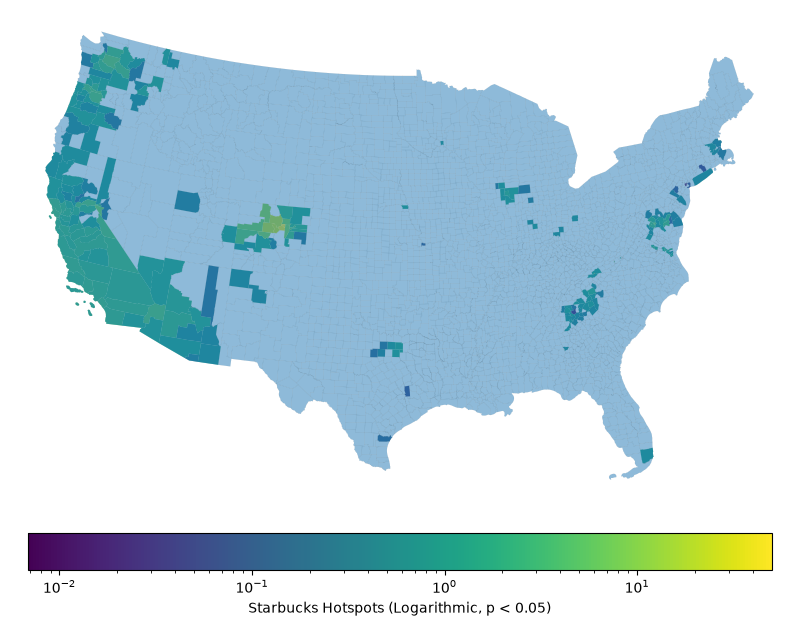

In [ ]:
fig3, ax3 = plt.subplots(figsize=(12, 8))

counties.plot(
	ax=ax3,
	facecolor='none',
	edgecolor='grey',
	linewidth=0.1,
	alpha=0.5
)

high_high.plot(
	ax=ax3,
    column='local_i',
    cmap='viridis',
    legend=True,
    norm=colors.LogNorm(vmin=high_high['local_i'].min(), vmax=high_high['local_i'].max()),
    figsize=(12, 8),
    legend_kwds={
        'label': "Starbucks Hotspots (Logarithmic, p < 0.05)",
        'orientation': "horizontal", 
        "shrink": 0.8,
        "pad": 0.05}
)

cs.plot(
	ax=ax3,
	alpha=0.5,
	column='stores_per_100k'
)

ax3.set_axis_off()

In [ ]:

query = """
with preliminary_checks as (
    select
    (select count(*) from cs where GEOID is null) as count_null,
	(select GEOID, count(*) from cs group by GEOID having count(*) > 1) as count_duplicate,
	(select count(*) from cs where geometry is null) as count_null_geometries,
	(select count(*) from cs where st_isempty(geometry)) as count_empty_geometries,
	(select GEOID, st_isvalidreason(geometry) from cs where not st_isvalid(geometry)) as count_invalid_geometry,
	(select st_srid(geometry), count(*) from cs group by st_srid(geometry) as count_srids)
), edge_pairs as (
    select
        a.GEOID as GEOID_a
        ,b.GEOID as GEOID_b
	    -- should be in EPSG:5070 already, a metric projected CRS
        st_length(
            st_collectionextract( -- only measure line components
                st_intersection(
                    st_boundary(a.geometry),
                    st_boundary(b.geometry)
                ),
                2
            )
        ) as shared_border_m
    from cs a
    join cs b
    -- eliminate duplicate pairs
    on a.GEOID < b.GEOID
    and st_intersects(a.geometry, b.geometry)
),
strict_edges as (
  select *
  from edge_pairs
  where shared_border_m > 0
),
directed_edges as (
  select GEOID_a as focal_fips, GEOID_b as neighbor_fips
  from strict_edges
  union all
  select GEOID_b as focal_fips, GEOID_a as neighbor_fips
  from strict_edges
),
neighbor_lists as (
    select
        c.GEOID as focal_fips
        ,coalesce(
            array_agg(de.neighbor_fips order by de.neighbor_fips)
                filter (where de.neighbor_fips is not null)
            ,array[]::text[]
        ) as neighbors
  from cs c
  left join directed_edges de
    on c.GEOID = de.focal_fips
  group by c.GEOID
),
validation as (
    select
        -- Every input county survives into output
        (
            select count(*)
            from cs
        ) as county_count,
		
        (
            select count(*)
            from neighbor_lists
        ) as output_count,
		
        -- Explicit islands
        (
            select count(*)
            from neighbor_lists
            where len(neighbors) = 0
        ) as island_count,

        -- No county can neighbor itself
        (
            select count(*)
            from directed_edges
            where focal_fips = neighbor_fips
        ) as self_edge_count,

        -- No duplicated directed relationships
        (
            select count(*) - count(distinct (focal_fips, neighbor_fips))
            from directed_edges
        ) as duplicate_edge_count,

        -- Every directed relationship has its reverse
        (
            select count(*)
            from directed_edges a
            left join directed_edges b
                on a.focal_fips = b.neighbor_fips
                and a.neighbor_fips = b.focal_fips
            where b.focal_fips is null
        ) as asymmetric_edge_count
    -- expect:
    -- county_count = output_count
    -- self_edge_count = 0
    -- duplicate_edge_count = 0
    -- asymmetric_edge_count = 0
)
select json_object_agg(focal_fips::text, neighbors) as neighbor_json
from neighbor_lists;
"""


df = con.execute(query).df()

df["geometry"] = df["geometry"].apply(bytes)

df["geometry"] = gpd.GeoSeries.from_wkb(
    df["geometry"]
    ,crs="EPSG:5070"
)

cs = gpd.GeoDataFrame(
    df
    ,geometry="geometry"
    ,crs="EPSG:5070"
)